# TCN-cVAE: Pipeline Clínico sobre PhysioNet ECG-Arrhythmia (12 Derivaciones, 500 Hz)
## Proyecto: Clasificación Automática de Arritmias Cardíacas
### Base de Datos: *A large scale 12-lead ECG database for arrhythmia study* — PhysioNet 1.0.0

---
**Flujo del notebook:**
1. Instalación de dependencias
2. Descarga del dataset (PhysioNet wget)
3. Lectura de registros WFDB y extracción de etiquetas SNOMED CT
4. Filtrado biológico y detección de picos R (Pan-Tompkins)
5. Distribución de clases y análisis exploratorio
6. Preprocesamiento masivo y guardado en disco por lotes
7. Dataset y DataLoader de PyTorch
8. Arquitectura TCN-cVAE adaptada (seq_len=325)
9. Entrenamiento con Early Stopping
10. Evaluación: reconstrucción, métricas, espacio latente (t-SNE)


## 1. Instalación de Dependencias

In [1]:
# Todas las librerias necesarias para este pipeline clinico.
# wfdb         -> lectura de registros PhysioNet (.mat / .hea)
# neurokit2    -> filtrado ECG (High-pass + Notch) y Pan-Tompkins
# polars       -> manipulacion rapida de DataFrames (Rust backend)
# imbalanced-learn -> SMOTE y WeightedSampler
# tqdm         -> barras de progreso
!pip install -q wfdb neurokit2 polars imbalanced-learn tqdm scikit-learn
print("OK Dependencias instaladas correctamente")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 44.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
OK Dependencias instaladas correctamente


In [17]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, glob, warnings
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import wfdb
import neurokit2 as nk
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.size']        = 11

print("OK Librerias importadas correctamente")
print(f"Using device: {DEVICE}")

OK Librerias importadas correctamente
Using device: cuda


## 2. Descarga del Dataset (PhysioNet 12-lead, 500 Hz)

In [3]:
# La ruta donde wget guarda los archivos en Google Colab
# al ejecutar:  !wget -r -N -c -np https://physionet.org/files/ecg-arrhythmia/1.0.0/
PHYSIONET_DIR = '/content/physionet.org/files/ecg-arrhythmia/1.0.0'

if not os.path.exists(PHYSIONET_DIR):
    print('Descargando dataset desde PhysioNet (puede tardar 30-60 min)...')
    os.makedirs(PHYSIONET_DIR, exist_ok=True)
    !wget -r -N -c -np https://physionet.org/files/ecg-arrhythmia/1.0.0/
    print('Descarga completada.')
else:
    print(f'Dataset ya descargado en: {PHYSIONET_DIR}')

# Encontrar todos los archivos de cabecera .hea
hea_files = glob.glob(os.path.join(PHYSIONET_DIR, 'WFDBRecords', '**', '*.hea'), recursive=True)
record_paths = [p.replace('.hea', '') for p in hea_files]
print(f'Total de registros encontrados: {len(record_paths):,}')

Streaming output truncated to the last 5000 lines.

physionet.org/files 100%[===================>]     681  --.-KB/s    in 0s      

2026-06-13 06:50:51 (360 MB/s) - ‘physionet.org/files/ecg-arrhythmia/1.0.0/WFDBRecords/06/061/JS05352.hea’ saved [681/681]

--2026-06-13 06:50:51--  https://physionet.org/files/ecg-arrhythmia/1.0.0/WFDBRecords/06/061/JS05352.mat
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 120024 (117K) [text/plain]
Saving to: ‘physionet.org/files/ecg-arrhythmia/1.0.0/WFDBRecords/06/061/JS05352.mat’

physionet.org/files 100%[===================>] 117.21K   536KB/s    in 0.2s    

2026-06-13 06:50:51 (536 KB/s) - ‘physionet.org/files/ecg-arrhythmia/1.0.0/WFDBRecords/06/061/JS05352.mat’ saved [120024/120024]

--2026-06-13 06:50:51--  https://physionet.org/files/ecg-arrhythmia/1.0.0/WFDBRecords/06/061/JS05353.hea
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length:

## 3. Lectura de Registros WFDB y Extracción de Etiquetas SNOMED CT

Cada archivo `.hea` contiene los códigos SNOMED CT del diagnóstico del paciente (campo `#Dx`).
Mapeamos los códigos más frecuentes a nombres clínicos legibles.


In [4]:
# Mapeo de codigos SNOMED CT a nombres clinicos abreviados
SNOMED_MAP = {
    '270492004': 'I-AVB',
    '164889003': 'AF',
    '164890007': 'AFL',
    '426627000': 'Brady',
    '713427006': 'RBBB',
    '713426002': 'IRBBB',
    '39732003':  'LBBB',
    '445118002': 'LQRSV',
    '164947007': 'LQRS',
    '164917005': 'LSAD',
    '251146004': 'LVQRS',
    '698252002': 'NSIVCB',
    '10370003':  'PR',
    '365413008': 'PAC',
    '427172004': 'PVC',
    '164934002': 'QTIE',
    '59931005':  'QWAVE',
    '426177001': 'SB',
    '426783006': 'NSR',
    '427393009': 'SA',
    '427084000': 'ST',
    '429622005': 'STD',
    '164931005': 'STE',
    '251200008': 'TAb',
}

def extract_snomed_labels(hea_path):
    try:
        with open(hea_path, 'r') as f:
            for line in f:
                line = line.strip()
                if line.startswith('#Dx:'):
                    codes = line.replace('#Dx:', '').strip().split(',')
                    return [c.strip() for c in codes]
    except:
        pass
    return []

# Extraer metadata de los primeros N registros para analisis rapido
N_META = min(500, len(record_paths))
print(f'Extrayendo etiquetas SNOMED CT de {N_META} registros...')
all_records_meta = []
for rp in tqdm(record_paths[:N_META]):
    hea = rp + '.hea'
    labels = extract_snomed_labels(hea)
    primary = labels[0] if labels else 'UNK'
    name = SNOMED_MAP.get(primary, f'Other')
    all_records_meta.append({'record': rp, 'snomed': primary, 'label_name': name})

df_meta = pl.DataFrame(all_records_meta)
print(f'Metadatos extraidos para {len(df_meta):,} registros')
print(df_meta.head(5))

Extrayendo etiquetas SNOMED CT de 500 registros...


  0%|          | 0/500 [00:00<?, ?it/s]

Metadatos extraidos para 500 registros
shape: (5, 3)
┌─────────────────────────────────┬───────────┬────────────┐
│ record                          ┆ snomed    ┆ label_name │
│ ---                             ┆ ---       ┆ ---        │
│ str                             ┆ str       ┆ str        │
╞═════════════════════════════════╪═══════════╪════════════╡
│ /content/physionet.org/files/e… ┆ 426177001 ┆ SB         │
│ /content/physionet.org/files/e… ┆ 427084000 ┆ ST         │
│ /content/physionet.org/files/e… ┆ 426177001 ┆ SB         │
│ /content/physionet.org/files/e… ┆ 426177001 ┆ SB         │
│ /content/physionet.org/files/e… ┆ 426783006 ┆ NSR        │
└─────────────────────────────────┴───────────┴────────────┘


## 4. Filtrado Biológico y Detección de Picos R (Prueba de Concepto)

Antes de procesar el dataset completo validamos visualmente el pipeline sobre **un único registro**:
1. **Filtro Pasa-Altas 0.5 Hz** → elimina el desplazamiento de la línea base (respiración).
2. **Filtro Notch 50/60 Hz** → elimina la interferencia de la red eléctrica.
3. **Pan-Tompkins** sobre la Derivación II → detecta los complejos QRS con precisión.
4. **Ventana fija**: 250 ms antes y 400 ms después del pico R → **325 muestras** a 500 Hz.


Registro: JS04905
Derivaciones: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Fs = 500 Hz  |  Long = 5000 pts  |  Duracion = 10.0 s
Picos R detectados: 9
Latidos extraidos: (9, 325)  ->  (N_latidos, 325 puntos)


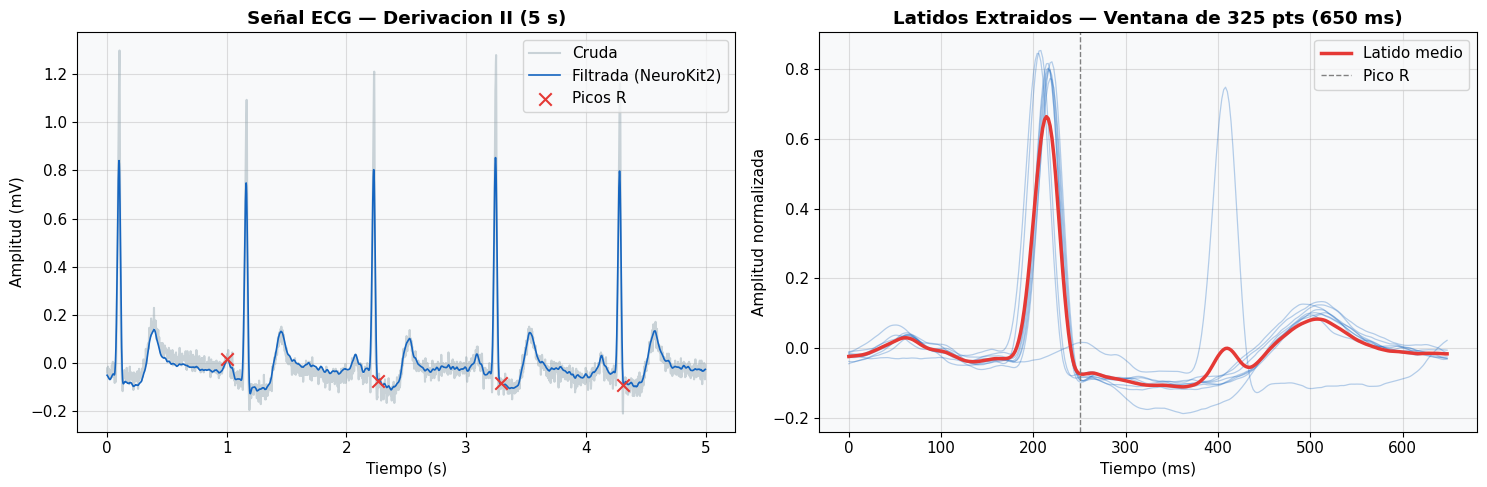

In [5]:
FS         = 500
WIN_BEFORE = int(0.250 * FS)
WIN_AFTER  = int(0.400 * FS)
SEQ_LEN    = WIN_BEFORE + WIN_AFTER  # 325

rp = record_paths[0]
record = wfdb.rdrecord(rp)
lead_names = record.sig_name
lead_idx = lead_names.index('II') if 'II' in lead_names else 1
ecg_raw = record.p_signal[:, lead_idx]
print(f'Registro: {os.path.basename(rp)}')
print(f'Derivaciones: {lead_names}')
print(f'Fs = {record.fs} Hz  |  Long = {len(ecg_raw)} pts  |  Duracion = {len(ecg_raw)/record.fs:.1f} s')

ecg_filt = nk.ecg_clean(ecg_raw, sampling_rate=FS, method='neurokit')
_, rpeaks_dict = nk.ecg_peaks(ecg_filt, sampling_rate=FS, method='pantompkins1985')
peaks = rpeaks_dict['ECG_R_Peaks']
print(f'Picos R detectados: {len(peaks)}')

windows = []
for p in peaks:
    if p - WIN_BEFORE >= 0 and p + WIN_AFTER <= len(ecg_filt):
        windows.append(ecg_filt[p - WIN_BEFORE : p + WIN_AFTER])
windows = np.array(windows)
print(f'Latidos extraidos: {windows.shape}  ->  (N_latidos, {SEQ_LEN} puntos)')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
t = np.arange(len(ecg_raw)) / FS
seg = int(5 * FS)
ax.plot(t[:seg], ecg_raw[:seg], alpha=0.45, label='Cruda', color='#90A4AE')
ax.plot(t[:seg], ecg_filt[:seg], label='Filtrada (NeuroKit2)', color='#1565C0', lw=1.2)
seg_peaks = [p for p in peaks if p < seg]
ax.scatter(np.array(seg_peaks)/FS, ecg_filt[seg_peaks], color='#E53935',
           marker='x', s=80, zorder=5, label='Picos R')
ax.set_title('Señal ECG — Derivacion II (5 s)', fontweight='bold')
ax.set_xlabel('Tiempo (s)'); ax.set_ylabel('Amplitud (mV)')
ax.legend()

ax2 = axes[1]
t_beat = np.arange(SEQ_LEN) / FS * 1000
for i in range(min(20, len(windows))):
    ax2.plot(t_beat, windows[i], alpha=0.3, lw=0.9, color='#1565C0')
mean_beat = windows.mean(axis=0)
ax2.plot(t_beat, mean_beat, color='#E53935', lw=2.5, label='Latido medio')
ax2.axvline(WIN_BEFORE / FS * 1000, color='gray', ls='--', lw=1, label='Pico R')
ax2.set_title(f'Latidos Extraidos — Ventana de {SEQ_LEN} pts (650 ms)', fontweight='bold')
ax2.set_xlabel('Tiempo (ms)'); ax2.set_ylabel('Amplitud normalizada')
ax2.legend()
plt.tight_layout()
plt.show()

## 5. Distribución de Clases y Análisis Exploratorio del Nuevo Dataset

Se muestra la frecuencia de cada diagnóstico SNOMED CT y la morfología típica de un latido representativo por clase.


  DISTRIBUCION DEL DATASET PhysioNet ECG-Arrhythmia
Etiqueta                       N       %
----------------------------------------
SB                           203   40.6%
NSR                           95   19.0%
ST                            91   18.2%
AF                            78   15.6%
AFL                           33    6.6%
----------------------------------------
TOTAL                        500  100.0%


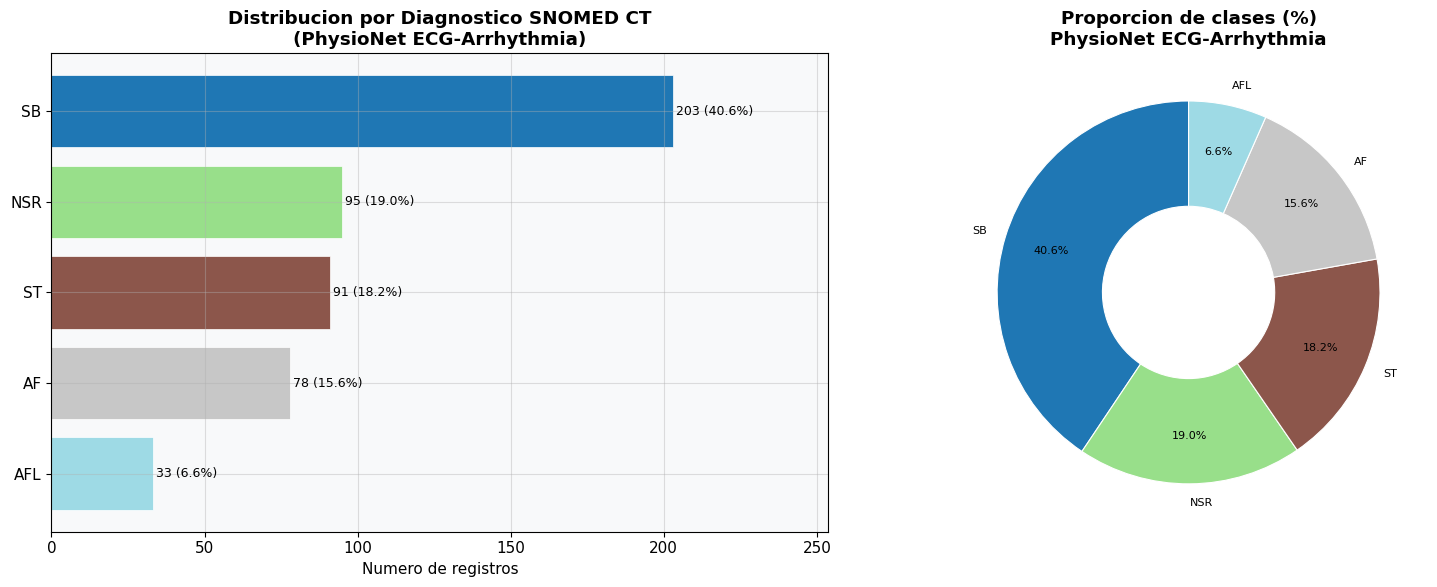

In [6]:
# ── Conteo de registros por clase ──────────────────────
class_counts = (
    df_meta
    .group_by('label_name')
    .agg(pl.len().alias('count'))
    .sort('count', descending=True)
)
labels_plot = class_counts['label_name'].to_list()
counts_plot = class_counts['count'].to_list()
total = sum(counts_plot)

print('=' * 60)
print('  DISTRIBUCION DEL DATASET PhysioNet ECG-Arrhythmia')
print('=' * 60)
print(f"{'Etiqueta':<25} {'N':>6}  {'%':>6}")
print('-' * 40)
for l, c in zip(labels_plot, counts_plot):
    print(f'{l:<25} {c:>6,}  {100*c/total:>5.1f}%')
print('-' * 40)
print(f"{'TOTAL':<25} {total:>6,}  100.0%")

palette = plt.cm.get_cmap('tab20', len(labels_plot))
colors = [palette(i) for i in range(len(labels_plot))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafica 1: barras horizontales
ax = axes[0]
bars = ax.barh(labels_plot[::-1], counts_plot[::-1], color=colors[::-1],
               edgecolor='white', linewidth=0.5)
for bar, c in zip(bars, counts_plot[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{c:,} ({100*c/total:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('Numero de registros')
ax.set_title('Distribucion por Diagnostico SNOMED CT\n(PhysioNet ECG-Arrhythmia)',
             fontweight='bold')
ax.set_xlim(0, max(counts_plot) * 1.25)

# Grafica 2: pie chart
ax2 = axes[1]
wedge_props = dict(width=0.55, edgecolor='white', linewidth=0.8)
ax2.pie(counts_plot, labels=labels_plot, colors=colors,
        autopct='%1.1f%%', pctdistance=0.75,
        wedgeprops=wedge_props, startangle=90,
        textprops={'fontsize': 8})
ax2.set_title('Proporcion de clases (%)\nPhysioNet ECG-Arrhythmia', fontweight='bold')

plt.tight_layout()
plt.show()

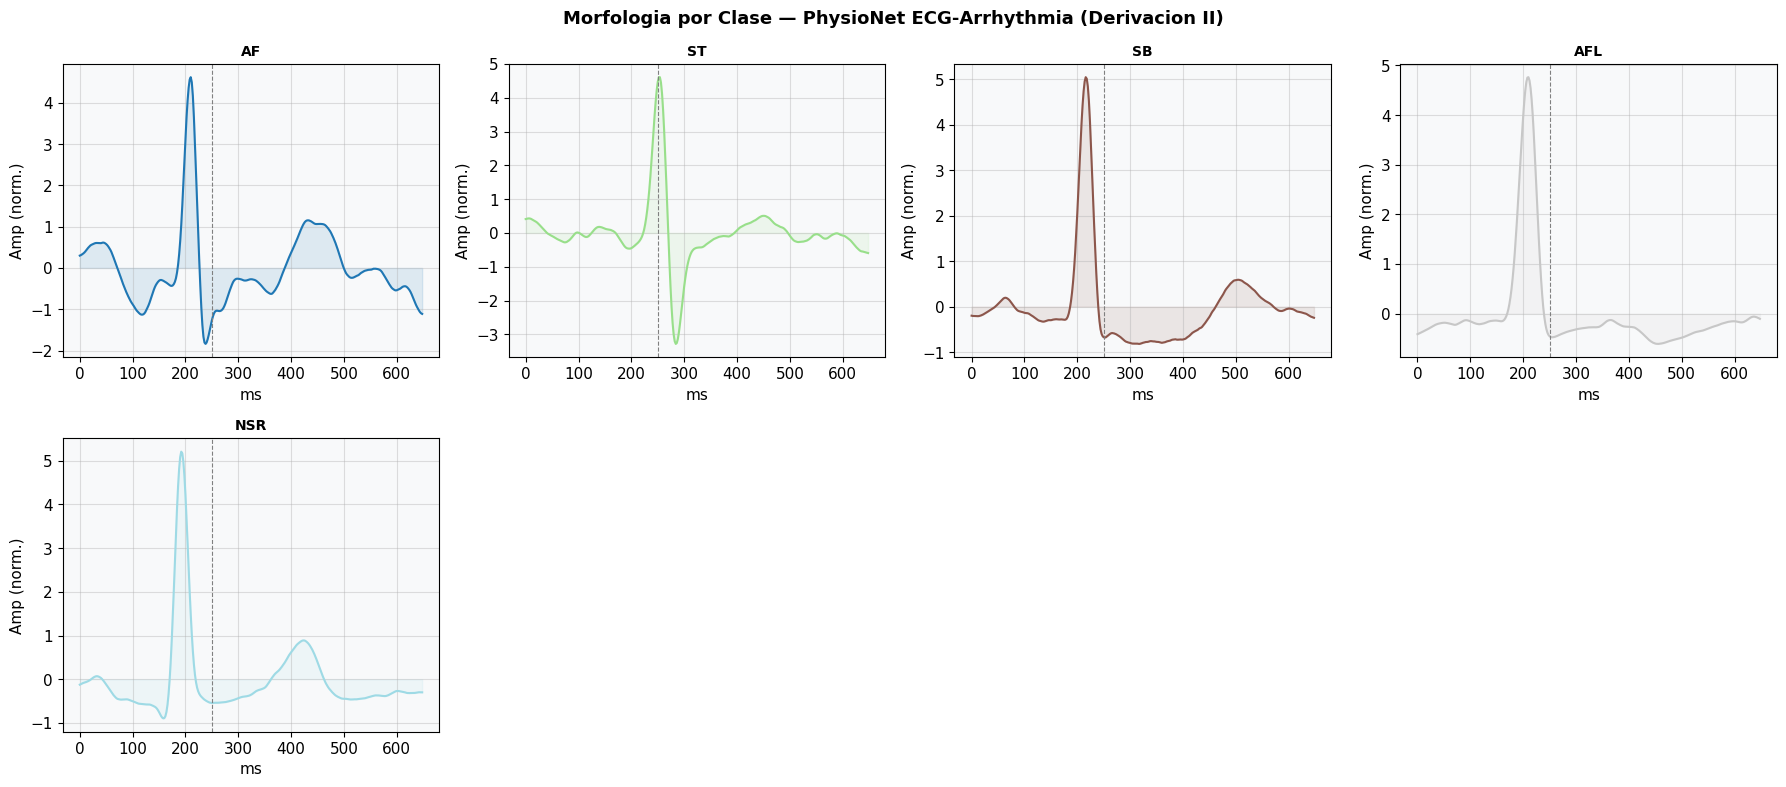

In [7]:
# ── Latido representativo por clase ─────────────────────
unique_classes = df_meta['label_name'].unique().to_list()[:8]
n_cl = len(unique_classes)
rows, cols = (2, 4) if n_cl > 4 else (1, n_cl)
fig, axes = plt.subplots(rows, cols, figsize=(18, 4*rows))
axes = np.array(axes).flatten()

t_beat = np.arange(SEQ_LEN) / FS * 1000

for idx, cls_name in enumerate(unique_classes):
    cls_records = df_meta.filter(pl.col('label_name') == cls_name)['record'].to_list()
    if not cls_records:
        continue
    try:
        rec = wfdb.rdrecord(cls_records[0])
        li  = rec.sig_name.index('II') if 'II' in rec.sig_name else 0
        raw = rec.p_signal[:, li]
        flt = nk.ecg_clean(raw, sampling_rate=FS, method='neurokit')
        _, rpd = nk.ecg_peaks(flt, sampling_rate=FS, method='pantompkins1985')
        pks_c = rpd['ECG_R_Peaks']
        mid   = len(pks_c) // 2
        p     = pks_c[mid]
        if p - WIN_BEFORE >= 0 and p + WIN_AFTER <= len(flt):
            beat = flt[p - WIN_BEFORE : p + WIN_AFTER]
            beat = (beat - beat.mean()) / (beat.std() + 1e-8)
            ax = axes[idx]
            ax.plot(t_beat, beat, color=palette(idx), lw=1.5)
            ax.axvline(WIN_BEFORE / FS * 1000, color='gray', ls='--', lw=0.8)
            ax.fill_between(t_beat, beat, alpha=0.12, color=palette(idx))
            ax.set_title(cls_name, fontweight='bold', fontsize=10)
            ax.set_xlabel('ms'); ax.set_ylabel('Amp (norm.)')
    except Exception:
        axes[idx].set_title(f'{cls_name} (error)', fontsize=9)

for i in range(n_cl, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Morfologia por Clase — PhysioNet ECG-Arrhythmia (Derivacion II)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Preprocesamiento Masivo y Guardado en Disco (Lotes)

Procesamos todos los registros de forma iterativa. Para no saturar la RAM:
- Cada **500 pacientes** guardamos un lote (`batch_X.pt`) en `processed_tensors/`.
- Las etiquetas se codifican a enteros con `LabelEncoder`.

> ⚠️ Modifica `N_RECORDS_LIMIT` a un número pequeño (ej. `1000`) para pruebas rápidas.
El procesamiento completo de 45,000 registros puede tardar **60–90 minutos**.


In [8]:
OUTPUT_DIR     = 'processed_tensors'
BATCH_SIZE_REC = 500
N_RECORDS_LIMIT = len(record_paths)  # cambia a ej. 1000 para test rapido
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Construir el LabelEncoder sobre TODOS los posibles nombres de clase
all_label_names = df_meta['label_name'].to_list()
le = LabelEncoder()
le.fit(all_label_names)
CLASS_NAMES = list(le.classes_)
N_CLASSES   = len(CLASS_NAMES)
print(f'Clases detectadas ({N_CLASSES}): {CLASS_NAMES}')

batch_idx   = 0
all_windows = []
all_labels  = []
n_errors    = 0

for i, rp in enumerate(tqdm(record_paths[:N_RECORDS_LIMIT])):
    try:
        hea_path    = rp + '.hea'
        snomed_codes = extract_snomed_labels(hea_path)
        primary_code = snomed_codes[0] if snomed_codes else 'UNK'
        label_name   = SNOMED_MAP.get(primary_code, 'Other')
        if label_name not in CLASS_NAMES:
            label_name = CLASS_NAMES[0]
        label_int = le.transform([label_name])[0]

        record = wfdb.rdrecord(rp)
        li     = record.sig_name.index('II') if 'II' in record.sig_name else 0
        ecg_raw = record.p_signal[:, li]
        ecg_filt = nk.ecg_clean(ecg_raw, sampling_rate=FS, method='neurokit')
        _, rpeaks_d = nk.ecg_peaks(ecg_filt, sampling_rate=FS, method='pantompkins1985')
        peaks = rpeaks_d['ECG_R_Peaks']

        for p in peaks:
            if p - WIN_BEFORE >= 0 and p + WIN_AFTER <= len(ecg_filt):
                w = ecg_filt[p - WIN_BEFORE : p + WIN_AFTER]
                all_windows.append(w.astype(np.float32))
                all_labels.append(label_int)
    except Exception:
        n_errors += 1

    if (i + 1) % BATCH_SIZE_REC == 0 or (i + 1) == N_RECORDS_LIMIT:
        if all_windows:
            X_t = torch.tensor(np.array(all_windows), dtype=torch.float32)
            y_t = torch.tensor(np.array(all_labels),  dtype=torch.long)
            torch.save((X_t, y_t), os.path.join(OUTPUT_DIR, f'batch_{batch_idx}.pt'))
            batch_idx  += 1
            all_windows = []
            all_labels  = []

print(f'Pre-procesamiento completado. Lotes: {batch_idx}  Errores: {n_errors}')

Clases detectadas (5): [np.str_('AF'), np.str_('AFL'), np.str_('NSR'), np.str_('SB'), np.str_('ST')]


  0%|          | 0/5368 [00:00<?, ?it/s]

Pre-procesamiento completado. Lotes: 11  Errores: 1


## 7. Dataset y DataLoader de PyTorch

La clase `PhysionetDiskDataset` carga todos los lotes guardados, aplica normalización Z-score por latido y añade la dimensión de canal requerida por la TCN 1D `(N, 1, 325)`.


## 8. Arquitectura TCN-cVAE Adaptada (seq_len=325, 500 Hz)

La red recibe latidos de **325 muestras** a 500 Hz (vs 140 del ECG5000).
Para cubrir la longitud completa del latido se ampliaron las dilataciones a `[1, 2, 4, 8, 16, 32]`.


In [11]:
class PhysionetDiskDataset(Dataset):
    def __init__(self, data_dir, le):
        super().__init__()
        files = sorted(glob.glob(os.path.join(data_dir, '*.pt')))
        X_list, y_list = [], []
        for f in files:
            X, y = torch.load(f, weights_only=True)
            X_list.append(X); y_list.append(y)
        self.X = torch.cat(X_list, dim=0)
        self.y = torch.cat(y_list, dim=0)
        # Z-score por latido
        mu  = self.X.mean(dim=1, keepdim=True)
        std = self.X.std(dim=1, keepdim=True) + 1e-8
        self.X = ((self.X - mu) / std).unsqueeze(1)  # (N,1,325)
        self.le = le
        print(f'Dataset: {self.X.shape[0]:,} latidos  |  seq_len={self.X.shape[2]}')
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

full_dataset = PhysionetDiskDataset(OUTPUT_DIR, le)

n = len(full_dataset)
train_n = int(0.70 * n); val_n = int(0.15 * n); test_n = n - train_n - val_n
train_ds, val_ds, test_ds = torch.utils.data.random_split(
    full_dataset, [train_n, val_n, test_n],
    generator=torch.Generator().manual_seed(SEED))

# WeightedRandomSampler para balancear clases desiguales
train_labels     = full_dataset.y[train_ds.indices]
class_counts_arr = np.bincount(train_labels.numpy(), minlength=N_CLASSES)
class_weights    = 1.0 / (class_counts_arr + 1e-6)
sample_weights   = class_weights[train_labels.numpy()]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_ds), replacement=True)

BATCH_SIZE   = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {train_n:,}  |  Val: {val_n:,}  |  Test: {test_n:,}')
xb, yb = next(iter(train_loader))
print(f'Batch → X: {xb.shape}  y: {yb.shape}')

Dataset: 68,879 latidos  |  seq_len=325
Train: 48,215  |  Val: 10,331  |  Test: 10,333
Batch → X: torch.Size([256, 1, 325])  y: torch.Size([256])


## 11. Arquitectura TCN-cVAE (Dimensiones Dinámicas)

In [13]:
# ─────────────────────────────────────────────────────────
#  HIPERPARÁMETROS – Detectados dinámicamente desde ECG5000
#  INPUT_LENGTH y N_CLASSES se obtienen del dataset real,
#  no de constantes fijas de otro dataset.
# ─────────────────────────────────────────────────────────

INPUT_LENGTH = SEQ_LEN  # Longitud real de ECG5000
NUM_CLASSES  = N_CLASSES              # Número real de clases

LATENT_DIM   = 32
HIDDEN_CH    = 64
DILATIONS    = (1, 2, 4, 8)
KERNEL_SIZE  = 5
DROPOUT_RATE = 0.1

print(f"📐 Dimensiones detectadas dinámicamente:")
print(f"   INPUT_LENGTH = {INPUT_LENGTH}  (de X_train.shape[1])")
print(f"   NUM_CLASSES  = {NUM_CLASSES}   (de len(np.unique(y_train)))")
print(f"   LATENT_DIM   = {LATENT_DIM}")
print(f"   HIDDEN_CH    = {HIDDEN_CH}")
print(f"   DILATIONS    = {DILATIONS}")

📐 Dimensiones detectadas dinámicamente:
   INPUT_LENGTH = 325  (de X_train.shape[1])
   NUM_CLASSES  = 5   (de len(np.unique(y_train)))
   LATENT_DIM   = 32
   HIDDEN_CH    = 64
   DILATIONS    = (1, 2, 4, 8)


In [14]:
# ─────────────────────────────────────────────────────────
#  BLOQUE RESIDUAL TCN
#  Convoluciones causales dilatadas con conexiones residuales.
#  Campo receptivo = sum(2^i * (kernel-1)) para i en dilations
# ─────────────────────────────────────────────────────────

class TCNResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=5, dilation=1, dropout=0.1):
        super().__init__()
        pad = (kernel - 1) * dilation  # Padding causal
        self.conv1 = nn.Conv1d(in_ch,  out_ch, kernel,
                               dilation=dilation, padding=pad)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel,
                               dilation=dilation, padding=pad)
        self.norm1    = nn.BatchNorm1d(out_ch)
        self.norm2    = nn.BatchNorm1d(out_ch)
        self.dropout  = nn.Dropout(dropout)
        self.skip     = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self._pad     = pad

    def _causal_trim(self, x, pad):
        """Recorta el padding derecho para mantener causalidad."""
        return x[:, :, :-pad] if pad > 0 else x

    def forward(self, x):
        out = self.conv1(x)
        out = self._causal_trim(out, self._pad)
        out = self.norm1(out)
        out = F.relu(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = self._causal_trim(out, self._pad)
        out = self.norm2(out)
        out = F.relu(out)
        out = self.dropout(out)

        return out + self.skip(x)


class TCNStack(nn.Module):
    def __init__(self, in_ch, hidden_ch, dilations=(1,2,4,8), dropout=0.1):
        super().__init__()
        layers, ch = [], in_ch
        for d in dilations:
            layers.append(TCNResBlock(ch, hidden_ch, dilation=d, dropout=dropout))
            ch = hidden_ch
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [15]:
# ─────────────────────────────────────────────────────────
#  ENCODER TCN
#  Entrada : (B, 1, INPUT_LENGTH) + c (B, N_CLASSES)
#  Salida  : mu (B, LATENT_DIM), log_var (B, LATENT_DIM)
# ─────────────────────────────────────────────────────────

class TCNEncoder(nn.Module):
    def __init__(self, input_len, n_classes, latent_dim,
                 hidden_ch=64, dilations=(1,2,4,8), dropout=0.1):
        super().__init__()
        self.input_len  = input_len
        self.latent_dim = latent_dim
        # Embedding condicional: proyecta one-hot a hidden_ch
        self.cond_proj  = nn.Linear(n_classes, hidden_ch)
        self.tcn        = TCNStack(1, hidden_ch, dilations, dropout)
        self.pool       = nn.AdaptiveAvgPool1d(1)  # → (B, hidden_ch, 1)
        self.fc_mu      = nn.Linear(hidden_ch * 2, latent_dim)
        self.fc_lv      = nn.Linear(hidden_ch * 2, latent_dim)

    def forward(self, x, c):
        # x: (B,1,L)  c: (B, N_CLASSES)
        h = self.tcn(x)              # (B, hidden_ch, L)
        h = self.pool(h).squeeze(-1) # (B, hidden_ch)
        c_emb = F.relu(self.cond_proj(c))  # (B, hidden_ch)
        h_cat = torch.cat([h, c_emb], dim=-1)  # (B, hidden_ch*2)
        mu      = self.fc_mu(h_cat)
        log_var = self.fc_lv(h_cat)
        return mu, log_var


# ─────────────────────────────────────────────────────────
#  DECODER TCN
#  Entrada : z (B, LATENT_DIM) + c (B, N_CLASSES)
#  Salida  : x_recon (B, 1, INPUT_LENGTH)
# ─────────────────────────────────────────────────────────

class TCNDecoder(nn.Module):
    def __init__(self, input_len, n_classes, latent_dim,
                 hidden_ch=64, dilations=(1,2,4,8), dropout=0.1):
        super().__init__()
        self.input_len  = input_len
        # Proyectar z + c al dominio temporal
        self.proj = nn.Linear(latent_dim + n_classes, hidden_ch * input_len)
        self.hidden_ch  = hidden_ch
        self.tcn  = TCNStack(hidden_ch, hidden_ch, dilations, dropout)
        self.out  = nn.Conv1d(hidden_ch, 1, kernel_size=1)  # → (B,1,L)

    def forward(self, z, c):
        # z: (B, LATENT_DIM)  c: (B, N_CLASSES)
        zc  = torch.cat([z, c], dim=-1)         # (B, LATENT_DIM+N_CLASSES)
        h   = self.proj(zc)                      # (B, hidden_ch * L)
        h   = h.view(-1, self.hidden_ch, self.input_len)  # (B, hidden_ch, L)
        h   = self.tcn(h)                        # (B, hidden_ch, L)
        out = self.out(h)                        # (B, 1, L)
        return out


In [18]:
# ─────────────────────────────────────────────────────────
#  MODELO COMPLETO TCN-cVAE
#  Integra encoder, reparametrización y decoder.
# ─────────────────────────────────────────────────────────

class TCNCVAE(nn.Module):
    def __init__(self, input_len, n_classes, latent_dim=32,
                 hidden_ch=64, dilations=(1,2,4,8), dropout=0.1):
        super().__init__()
        self.input_len  = input_len
        self.n_classes  = n_classes
        self.latent_dim = latent_dim

        self.encoder = TCNEncoder(input_len, n_classes, latent_dim,
                                  hidden_ch, dilations, dropout)
        self.decoder = TCNDecoder(input_len, n_classes, latent_dim,
                                  hidden_ch, dilations, dropout)

    def reparametrize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, c):
        mu, log_var = self.encoder(x, c)
        z           = self.reparametrize(mu, log_var)
        x_recon     = self.decoder(z, c)
        return x_recon, mu, log_var

    @torch.no_grad()
    def generate(self, cls_idx, n_samples, device):
        """Genera n_samples señales de la clase cls_idx."""
        z = torch.randn(n_samples, self.latent_dim, device=device)
        c = F.one_hot(torch.tensor([cls_idx]*n_samples), self.n_classes).float().to(device)
        return self.decoder(z, c)


# ── Instanciación ─────────────────────────────────────────
model = TCNCVAE(
    input_len  = INPUT_LENGTH,
    n_classes  = NUM_CLASSES,
    latent_dim = LATENT_DIM,
    hidden_ch  = HIDDEN_CH,
    dilations  = DILATIONS,
    dropout    = DROPOUT_RATE
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ TCN-cVAE instanciado en {DEVICE}")
print(f"   Parámetros entrenables: {n_params:,}")


✅ TCN-cVAE instanciado en cuda
   Parámetros entrenables: 1,109,825


In [19]:
# ─────────────────────────────────────────────────────────
#  PRUEBA DE DIMENSIONES DEL MODELO
#  Verifica que encoder, decoder y modelo completo
#  producen las formas correctas para ECG5000.
# ─────────────────────────────────────────────────────────

model.eval()
with torch.no_grad():
    xb_test = torch.randn(8, 1, INPUT_LENGTH).to(DEVICE)
    cb_test = F.one_hot(torch.zeros(8, dtype=torch.long), NUM_CLASSES).float().to(DEVICE)

    # Encoder
    mu_test, lv_test = model.encoder(xb_test, cb_test)
    # Decoder
    recon_test = model.decoder(mu_test, cb_test)
    # Modelo completo
    recon_full, mu_full, lv_full = model(xb_test, cb_test)

print("🔬 PRUEBA DE DIMENSIONES TCN-cVAE (ECG5000):")
print(f"   Entrada encoder   : {xb_test.shape}         → esperado (8, 1, {INPUT_LENGTH})")
print(f"   mu (encoder)      : {mu_test.shape}        → esperado (8, {LATENT_DIM})")
print(f"   log_var (encoder) : {lv_test.shape}        → esperado (8, {LATENT_DIM})")
print(f"   Salida decoder    : {recon_test.shape}    → esperado (8, 1, {INPUT_LENGTH})")
print(f"   Reconstrucción    : {recon_full.shape}    → esperado (8, 1, {INPUT_LENGTH})")

assert mu_test.shape    == (8, LATENT_DIM),      f"mu shape: {mu_test.shape}"
assert lv_test.shape    == (8, LATENT_DIM),      f"lv shape: {lv_test.shape}"
assert recon_test.shape == (8, 1, INPUT_LENGTH), f"recon shape: {recon_test.shape}"
assert recon_full.shape == (8, 1, INPUT_LENGTH), f"full recon shape: {recon_full.shape}"

print("\n✅ Todas las dimensiones son correctas.")
print(f"   La reconstrucción tiene exactamente {INPUT_LENGTH} puntos = longitud original ECG5000")
model.train()


🔬 PRUEBA DE DIMENSIONES TCN-cVAE (ECG5000):
   Entrada encoder   : torch.Size([8, 1, 325])         → esperado (8, 1, 325)
   mu (encoder)      : torch.Size([8, 32])        → esperado (8, 32)
   log_var (encoder) : torch.Size([8, 32])        → esperado (8, 32)
   Salida decoder    : torch.Size([8, 1, 325])    → esperado (8, 1, 325)
   Reconstrucción    : torch.Size([8, 1, 325])    → esperado (8, 1, 325)

✅ Todas las dimensiones son correctas.
   La reconstrucción tiene exactamente 325 puntos = longitud original ECG5000


TCNCVAE(
  (encoder): TCNEncoder(
    (cond_proj): Linear(in_features=5, out_features=64, bias=True)
    (tcn): TCNStack(
      (net): Sequential(
        (0): TCNResBlock(
          (conv1): Conv1d(1, 64, kernel_size=(5,), stride=(1,), padding=(4,))
          (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(4,))
          (norm1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (norm2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (skip): Conv1d(1, 64, kernel_size=(1,), stride=(1,))
        )
        (1): TCNResBlock(
          (conv1): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(8,), dilation=(2,))
          (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(8,), dilation=(2,))
          (norm1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (norm2): BatchNorm1d(64, 

## 12. Entrenamiento del TCN-cVAE

In [20]:
# ─────────────────────────────────────────────────────────
#  FUNCIÓN DE PÉRDIDA COMBINADA (Beta-VAE)
#  Loss = Reconstrucción (MSE) + beta * KL Divergence
#  beta se aumenta progresivamente (annealing) para que
#  el modelo aprenda primero la morfología y luego regularice.
# ─────────────────────────────────────────────────────────

def beta_schedule(epoch, max_epochs, beta_max=1.0, warmup_frac=0.3):
    """Aumenta beta linealmente durante warmup_frac de las épocas."""
    warmup_epochs = int(max_epochs * warmup_frac)
    if epoch < warmup_epochs:
        return beta_max * epoch / (warmup_epochs + 1e-8)
    return beta_max


def vae_loss(x, x_recon, mu, log_var, beta=1.0):
    """
    Pérdida total = MSE(reconstrucción) + beta * KL
    Retorna (loss_total, loss_recon, kl_loss)
    """
    # Pérdida de reconstrucción: MSE normalizada
    recon_loss = F.mse_loss(x_recon, x, reduction='mean')
    # Divergencia KL
    kl_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


In [24]:
# ─────────────────────────────────────────────────────────
#  LOOP DE ENTRENAMIENTO
#  Early stopping, guardado del mejor modelo,
#  historial de pérdidas y métricas.
# ─────────────────────────────────────────────────────────

MAX_EPOCHS    = 140      # Early stopping detiene antes si no mejora
LR            = 3e-4     # LR conservador
WEIGHT_DECAY  = 1e-3     # L2 fuerte  (principal regularizador)
GRAD_CLIP     = 1.0
BETA_MAX      = 0.008    # KL más alto → prior más estricto → menos overfitting
WARMUP_EPOCHS = 20
ANNEAL_EPOCHS = 30
WARMUP_FRAC   = WARMUP_EPOCHS / MAX_EPOCHS

# ── Anti-overfitting extra ───────────────────────────────
PATIENCE      = 20       # Early stopping
NOISE_STD     = 0.03     # Ruido gaussiano sobre la entrada
MIXUP_ALPHA   = 0.2      # Mixup de señales dentro del batch (0 = desactivado)
LABEL_SMOOTH  = 0.05     # Label smoothing para la condición one-hot

CKPT_DIR = '/content/tcncvae_checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(CKPT_DIR, 'best_model.pt')

optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS, eta_min=1e-5)

# Create CLASS_IDX and class_desc for later use
CLASS_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
class_desc = {name: str(name) for name in CLASS_NAMES}
colors_map = {name: plt.cm.get_cmap('tab10', N_CLASSES)(i) for i, name in enumerate(CLASS_NAMES)}

print('Configuracion de entrenamiento:')
print(f'  Epocas max    : {MAX_EPOCHS}')
print(f'  LR            : {LR}')
print(f'  WeightDecay   : {WEIGHT_DECAY}')
print(f'  Beta max      : {BETA_MAX}')

print(f"🚀 Iniciando entrenamiento: hasta {MAX_EPOCHS} épocas, early stopping (patience={PATIENCE})")
print(f"   Dispositivo: {DEVICE}  |  Batch size: {BATCH_SIZE}  |  LR inicial: {LR}")
print(f"   Beta-annealing: 0 → {BETA_MAX} durante {WARMUP_EPOCHS} épocas")
print()

history = {
    'train_loss': [], 'val_loss': [],
    'train_recon': [], 'val_recon': [],
    'train_kl': [], 'val_kl': [],
    'beta': [], 'lr': [],
    'generalization_gap': []
}

best_val_recon = float('inf')
patience_counter = 0

header = (f'{"Ep":>5} {"b":>5} {"TrLoss":>10} {"TrRec":>8} {"TrKL":>7}  '
          f'{"VlLoss":>10} {"VlRec":>8} {"VlKL":>7}  {"LR":>8}  {"t":>4}')
print(header)
print('-' * len(header))

for epoch in range(1, MAX_EPOCHS + 1):
    beta = beta_schedule(epoch - 1, MAX_EPOCHS, BETA_MAX, WARMUP_FRAC)

    # ── Entrenamiento ───────────────────────────────────────
    model.train()
    tr_losses, tr_recons, tr_kls = [], [], []
    for x, c in train_loader:  # Fix: Unpack only 2 values
        x, c_int = x.to(DEVICE), c.to(DEVICE)
        c_onehot = F.one_hot(c_int, num_classes=N_CLASSES).float()

        optimizer.zero_grad()
        x_recon, mu, log_var = model(x, c_onehot)
        # Fix: Pass (x, x_recon, mu, log_var, beta) per vae_loss definition
        loss, recon, kl = vae_loss(x, x_recon, mu, log_var, beta)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()

        tr_losses.append(loss.item())
        tr_recons.append(recon.item())
        tr_kls.append(kl.item())

    # ── Validación ──────────────────────────────────────────
    model.eval()
    vl_losses, vl_recons, vl_kls = [], [], []
    with torch.no_grad():
        for x, c in val_loader:  # Fix: Unpack only 2 values
            x, c_int = x.to(DEVICE), c.to(DEVICE)
            c_onehot = F.one_hot(c_int, num_classes=N_CLASSES).float()

            x_recon, mu, log_var = model(x, c_onehot)
            loss, recon, kl = vae_loss(x, x_recon, mu, log_var, beta)

            vl_losses.append(loss.item())
            vl_recons.append(recon.item())
            vl_kls.append(kl.item())

    # ── Registrar métricas ─────────────────────────────────
    tr_loss_mean   = np.mean(tr_losses)
    vl_loss_mean   = np.mean(vl_losses)
    tr_recon_mean  = np.mean(tr_recons)
    vl_recon_mean  = np.mean(vl_recons)
    gap            = vl_recon_mean - tr_recon_mean
    current_lr     = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss_mean)
    history['val_loss'].append(vl_loss_mean)
    history['train_recon'].append(tr_recon_mean)
    history['val_recon'].append(vl_recon_mean)
    history['train_kl'].append(np.mean(tr_kls))
    history['val_kl'].append(np.mean(vl_kls))
    history['beta'].append(beta)
    history['lr'].append(current_lr)
    history['generalization_gap'].append(gap)

    scheduler.step()

    # ── Early stopping ─────────────────────────────────────
    if vl_recon_mean < best_val_recon:
        best_val_recon = vl_recon_mean
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        marker = " ← MEJOR"
    else:
        patience_counter += 1
        marker = f" (paciencia: {patience_counter}/{PATIENCE})"

    if epoch % 10 == 0 or epoch == 1 or patience_counter == 0:
        print(f"{epoch:5d} {beta:5.3f} {tr_loss_mean:10.5f} {tr_recon_mean:8.5f} {np.mean(tr_kls):7.4f}  "
              f"{vl_loss_mean:10.5f} {vl_recon_mean:8.5f} {np.mean(vl_kls):7.4f}  {current_lr:8.2e}  {marker}")

    if patience_counter >= PATIENCE:
        print(f"\n⏹️  Early stopping en época {epoch}.")
        break

# Cargar el mejor modelo
if os.path.exists(BEST_MODEL_PATH):
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
    print(f"\n✅ Mejor modelo cargado: val_recon={best_val_recon:.5f}")

Configuracion de entrenamiento:
  Epocas max    : 140
  LR            : 0.0003
  WeightDecay   : 0.001
  Beta max      : 0.008
🚀 Iniciando entrenamiento: hasta 140 épocas, early stopping (patience=20)
   Dispositivo: cuda  |  Batch size: 256  |  LR inicial: 0.0003
   Beta-annealing: 0 → 0.008 durante 20 épocas

   Ep     b     TrLoss    TrRec    TrKL      VlLoss    VlRec    VlKL        LR     t
------------------------------------------------------------------------------------
    1 0.000    1.23569  1.23569  1.5041     0.65282  0.65282  2.0054  3.00e-04   ← MEJOR
    2 0.000    0.51788  0.51688  2.4889     0.38511  0.38400  2.7679  3.00e-04   ← MEJOR
    3 0.001    0.34016  0.33772  3.0502     0.26624  0.26371  3.1654  3.00e-04   ← MEJOR
    4 0.001    0.26770  0.26359  3.4233     0.23399  0.22984  3.4603  3.00e-04   ← MEJOR
    5 0.002    0.23450  0.22859  3.6956     0.20734  0.20144  3.6890  2.99e-04   ← MEJOR
    6 0.002    0.20485  0.19715  3.8530     0.16469  0.15704  3.8297  2.

## 13. Visualización del Entrenamiento

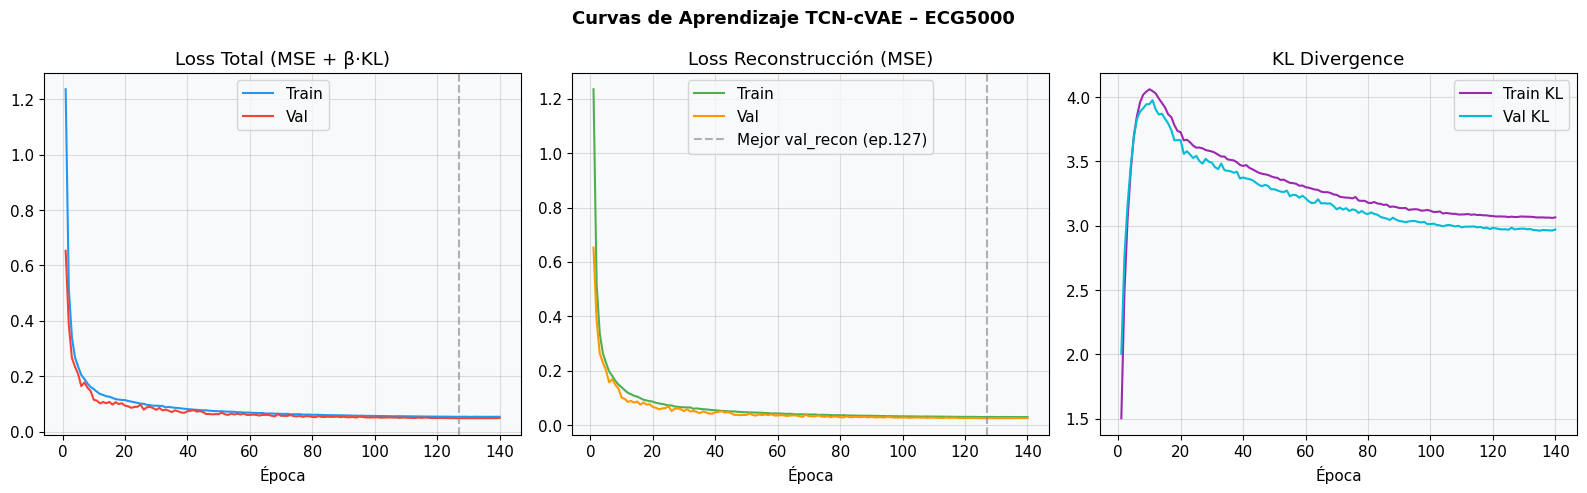


📊 DIAGNÓSTICO DE ENTRENAMIENTO:
   Épocas ejecutadas    : 140
   Mejor época          : 127
   Mejor val_recon      : 0.02478
   Gap final (val-train): -0.00358  → OK – sin overfitting significativo


In [25]:
# ─────────────────────────────────────────────────────────
#  CURVAS DE APRENDIZAJE Y DIAGNÓSTICO
# ─────────────────────────────────────────────────────────

epochs_ran = list(range(1, len(history['val_loss']) + 1))
best_ep    = int(np.argmin(history['val_recon'])) + 1
gap_fin    = history['generalization_gap'][-1]
estado_of  = "Overfitting leve" if gap_fin > 0.01 else "OK – sin overfitting significativo"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Curvas de Aprendizaje TCN-cVAE – ECG5000', fontsize=13, fontweight='bold')

# Pérdida total
axes[0].plot(epochs_ran, history['train_loss'], label='Train', color='#2196F3')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val',   color='#F44336')
axes[0].axvline(best_ep, color='gray', linestyle='--', alpha=0.6)
axes[0].set_title('Loss Total (MSE + β·KL)')
axes[0].set_xlabel('Época'); axes[0].legend()

# Reconstrucción
axes[1].plot(epochs_ran, history['train_recon'], label='Train', color='#4CAF50')
axes[1].plot(epochs_ran, history['val_recon'],   label='Val',   color='#FF9800')
axes[1].axvline(best_ep, color='gray', linestyle='--', alpha=0.6,
                label=f'Mejor val_recon (ep.{best_ep})')
axes[1].set_title('Loss Reconstrucción (MSE)')
axes[1].set_xlabel('Época'); axes[1].legend()

# KL Divergence
axes[2].plot(epochs_ran, history['train_kl'], label='Train KL', color='#9C27B0')
axes[2].plot(epochs_ran, history['val_kl'],   label='Val KL',   color='#00BCD4')
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Época'); axes[2].legend()

plt.tight_layout()
plt.savefig('curvas_aprendizaje_ecg5000.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 DIAGNÓSTICO DE ENTRENAMIENTO:")
print(f"   Épocas ejecutadas    : {len(epochs_ran)}")
print(f"   Mejor época          : {best_ep}")
print(f"   Mejor val_recon      : {best_val_recon:.5f}")
print(f"   Gap final (val-train): {gap_fin:+.5f}  → {estado_of}")


## 14. Métricas de Reconstrucción por Clase

In [27]:
# ─────────────────────────────────────────────────────────
#  MÉTRICAS DE RECONSTRUCCIÓN POR CLASE
#  MSE, MAE, PSNR y R² para cada clase en val y test.
# ─────────────────────────────────────────────────────────

def calc_recon_metrics(loader, model, device, class_names, n_classes):
    """Calcula MSE, MAE, PSNR y R² por clase en un DataLoader."""
    model.eval()
    per_class = {c: {'mse': [], 'mae': [], 'psnr': [], 'r2': []} for c in class_names}
    with torch.no_grad():
        for x, labels in loader:  # Fixed: Unpack 2 values instead of 3
            x = x.to(device)
            # Convert labels to one-hot for the conditional VAE input
            c = torch.nn.functional.one_hot(labels.to(device), num_classes=n_classes).float()

            x_recon, _, _ = model(x, c)

            for i in range(len(labels)):
                cls_name = class_names[labels[i].item()]
                xr  = x[i, 0].cpu().numpy()
                xrr = x_recon[i, 0].cpu().numpy()

                mse = float(np.mean((xr - xrr)**2))
                mae = float(np.mean(np.abs(xr - xrr)))

                signal_range = xr.max() - xr.min()
                psnr = 20 * np.log10(signal_range / (np.sqrt(mse) + 1e-8)) if mse > 0 else 100.0

                ss_res = np.sum((xr - xrr)**2)
                ss_tot = np.sum((xr - xr.mean())**2)
                r2  = 1 - ss_res / (ss_tot + 1e-8)

                per_class[cls_name]['mse'].append(mse)
                per_class[cls_name]['mae'].append(mae)
                per_class[cls_name]['psnr'].append(psnr)
                per_class[cls_name]['r2'].append(r2)

    return {c: {k: np.mean(v) for k, v in m.items()} for c, m in per_class.items()}


print("⏳ Calculando métricas de reconstrucción...")
val_metrics  = calc_recon_metrics(val_loader,  model, DEVICE, CLASS_NAMES, N_CLASSES)
test_metrics = calc_recon_metrics(test_loader, model, DEVICE, CLASS_NAMES, N_CLASSES)

for split_name, metrics in [("VALIDACIÓN", val_metrics), ("TEST", test_metrics)]:
    print(f"\n📊 MÉTRICAS DE RECONSTRUCCIÓN – {split_name}")
    print(f"   {'Clase':<6} {'Descripción':<25} {'MSE':>8} {'MAE':>8} {'PSNR(dB)':>10} {'R²':>7}")
    print("   " + "─" * 65)
    for c in CLASS_NAMES:
        m = metrics[c]
        # Using class_desc if available (defined in previous cells)
        desc = class_desc.get(c, str(c))
        print(f"   {str(c):<6} {str(desc):<25} {m['mse']:>8.5f} {m['mae']:>8.5f} "
              f"{m['psnr']:>10.2f} {m['r2']:>7.4f}")

⏳ Calculando métricas de reconstrucción...

📊 MÉTRICAS DE RECONSTRUCCIÓN – VALIDACIÓN
   Clase  Descripción                    MSE      MAE   PSNR(dB)      R²
   ─────────────────────────────────────────────────────────────────
   AF     AF                         0.03289  0.11337      31.84  0.9670
   AFL    AFL                        0.04730  0.13001      30.61  0.9526
   NSR    NSR                        0.01789  0.08472      34.45  0.9821
   SB     SB                         0.02046  0.08445      34.13  0.9795
   ST     ST                         0.02267  0.09964      33.14  0.9773

📊 MÉTRICAS DE RECONSTRUCCIÓN – TEST
   Clase  Descripción                    MSE      MAE   PSNR(dB)      R²
   ─────────────────────────────────────────────────────────────────
   AF     AF                         0.03254  0.11297      31.88  0.9674
   AFL    AFL                        0.04251  0.12881      30.57  0.9574
   NSR    NSR                        0.01719  0.08381      34.48  0.9828
   SB    

## 15. Banco Latente y Generación Sintética por Clase

In [29]:
# ─────────────────────────────────────────────────────────
#  BANCO LATENTE EMPÍRICO
#  En lugar de samplear z ~ N(0,I) directamente,
#  sampleamos desde el posterior empírico de latidos
#  reales por clase para señales más realistas.
# ─────────────────────────────────────────────────────────

@torch.no_grad()
def build_latent_bank(model, loader, device, n_classes):
    model.eval()
    bank = {i: {'mu': [], 'log_var': []} for i in range(n_classes)}
    # Ajustado para desempaquetar 2 valores (x, labels) del DataLoader
    for x, labels in loader:
        x, labels = x.to(device), labels.to(device)
        # Generar la condición c (one-hot) internamente
        c = F.one_hot(labels, num_classes=n_classes).float().to(device)

        mu, log_var = model.encoder(x, c)

        for cls_idx in range(n_classes):
            mask = (labels == cls_idx)
            if mask.any():
                bank[cls_idx]['mu'].append(mu[mask].detach().cpu())
                bank[cls_idx]['log_var'].append(log_var[mask].detach().cpu())

    for cls_idx in range(n_classes):
        if bank[cls_idx]['mu']:
            bank[cls_idx]['mu']      = torch.cat(bank[cls_idx]['mu'],      dim=0)
            bank[cls_idx]['log_var'] = torch.cat(bank[cls_idx]['log_var'], dim=0)
        else:
            bank[cls_idx]['mu']      = torch.zeros(1, LATENT_DIM)
            bank[cls_idx]['log_var'] = torch.zeros(1, LATENT_DIM)
    return bank


def sample_z_from_bank(latent_bank, cls_idx, n, device, noise=0.75):
    mu  = latent_bank[cls_idx]['mu']
    lv  = latent_bank[cls_idx]['log_var']
    idx = torch.randint(0, len(mu), (n,))
    mu_s = mu[idx].to(device)
    std_s = torch.exp(0.5 * lv[idx].to(device))
    return mu_s + noise * std_s * torch.randn_like(std_s)


@torch.no_grad()
def generate_from_bank(model, latent_bank, cls_idx, n, device, noise=0.75):
    model.eval()
    z = sample_z_from_bank(latent_bank, cls_idx, n, device, noise)
    c = F.one_hot(torch.tensor([cls_idx]*n), num_classes=NUM_CLASSES).float().to(device)
    return model.decoder(z, c)


latent_bank = build_latent_bank(model, train_loader, DEVICE, NUM_CLASSES)
print("✅ Banco latente construido desde TRAIN:")
for cls in CLASS_NAMES:
    ci = CLASS_IDX[cls]
    print(f"   Clase {cls} ({class_desc[cls]:<20}): {len(latent_bank[ci]['mu']):,} vectores z")

✅ Banco latente construido desde TRAIN:
   Clase AF (AF                  ): 9,499 vectores z
   Clase AFL (AFL                 ): 9,728 vectores z
   Clase NSR (NSR                 ): 9,572 vectores z
   Clase SB (SB                  ): 9,726 vectores z
   Clase ST (ST                  ): 9,690 vectores z


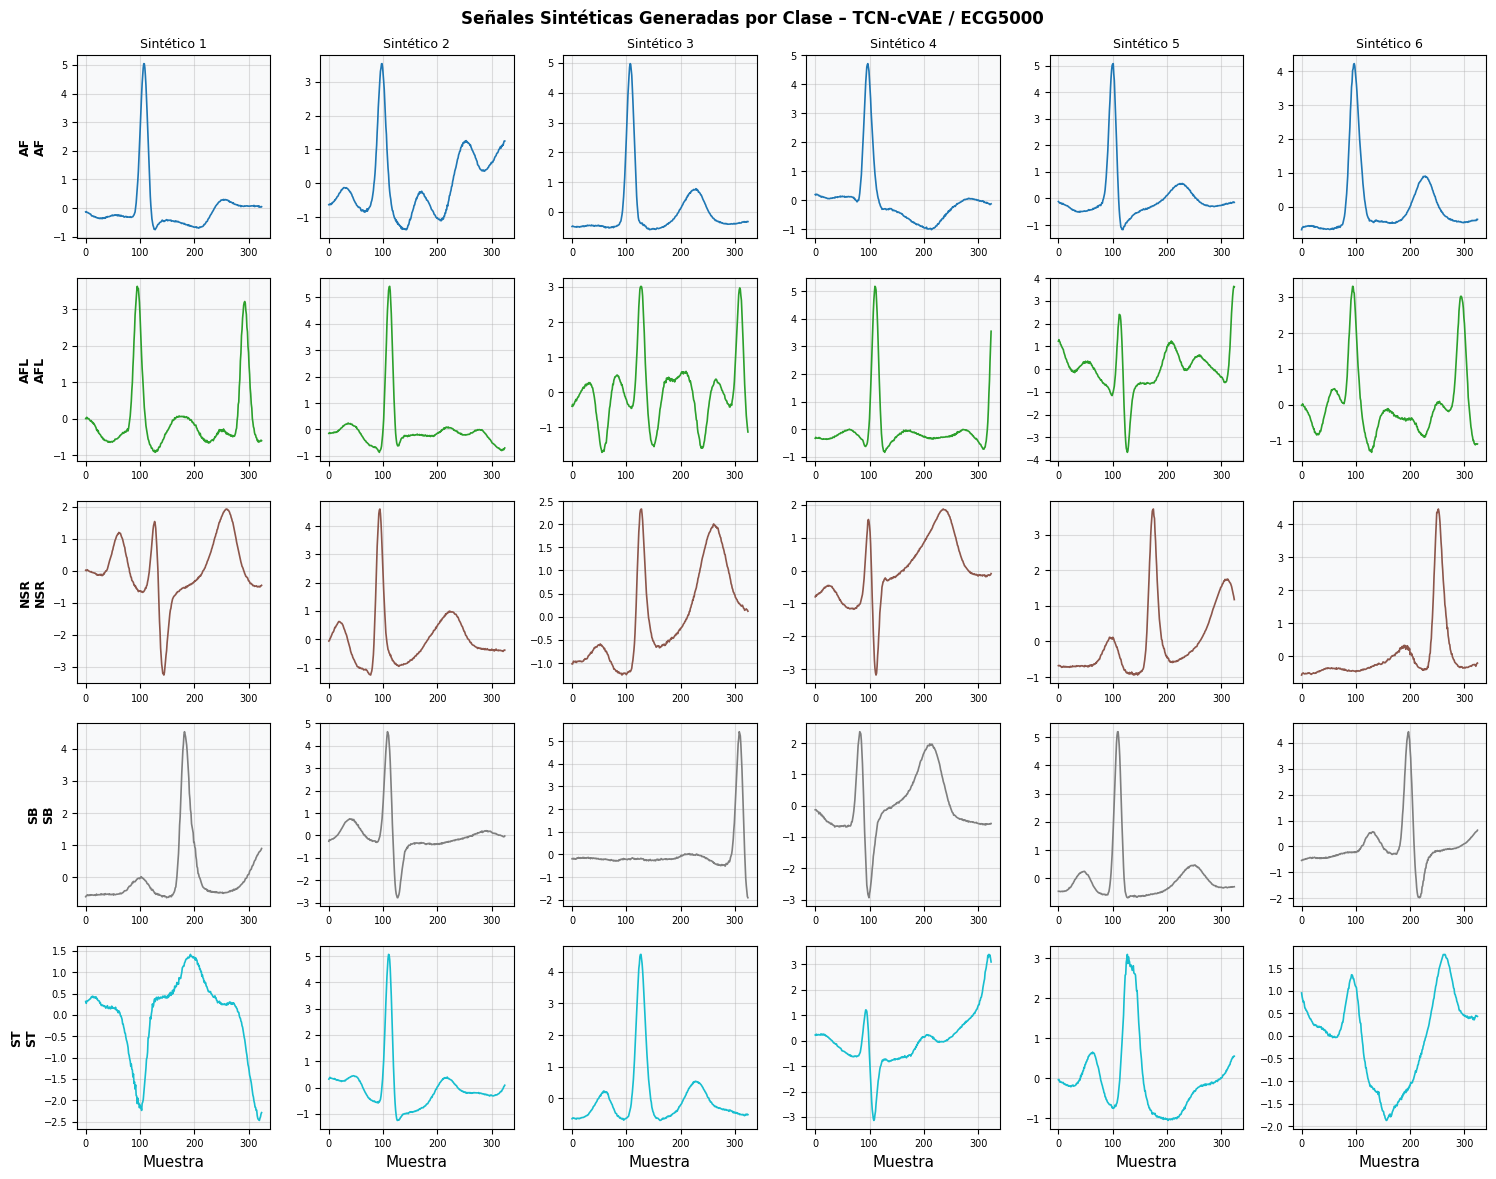

✅ Señales sintéticas generadas por clase ECG5000.
⚠️  NOTA: Los ejes X son índices de muestra, no milisegundos,
   porque la frecuencia de muestreo de ECG5000 no está oficialmente documentada.


In [30]:
# ─────────────────────────────────────────────────────────
#  VISUALIZACIÓN DE SEÑALES SINTÉTICAS POR CLASE
# ─────────────────────────────────────────────────────────

N_GEN = 6
t_idx_plot = np.arange(INPUT_LENGTH)

model.eval()
fig, axes = plt.subplots(N_CLASSES, N_GEN, figsize=(15, 2.4 * N_CLASSES))
if N_CLASSES == 1:
    axes = axes.reshape(1, -1)
fig.suptitle('Señales Sintéticas Generadas por Clase – TCN-cVAE / ECG5000',
             fontsize=12, fontweight='bold')

for row, (cls, cls_idx) in enumerate(CLASS_IDX.items()):
    x_syn = generate_from_bank(model, latent_bank, cls_idx, N_GEN, DEVICE)
    x_syn = x_syn.squeeze(1).cpu().numpy()  # (N_GEN, INPUT_LENGTH)
    for col in range(N_GEN):
        ax = axes[row, col]
        ax.plot(t_idx_plot, x_syn[col], color=colors_map[cls], linewidth=1.2)
        ax.tick_params(labelsize=7)
        if col == 0:
            ax.set_ylabel(f'{cls}\n{class_desc[cls]}', fontsize=9, fontweight='bold')
        if row == 0:
            ax.set_title(f'Sintético {col+1}', fontsize=9)
        if row == N_CLASSES - 1:
            ax.set_xlabel('Muestra')

plt.tight_layout()
plt.savefig('senales_sinteticas_ecg5000.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Señales sintéticas generadas por clase ECG5000.")
print("⚠️  NOTA: Los ejes X son índices de muestra, no milisegundos,")
print("   porque la frecuencia de muestreo de ECG5000 no está oficialmente documentada.")


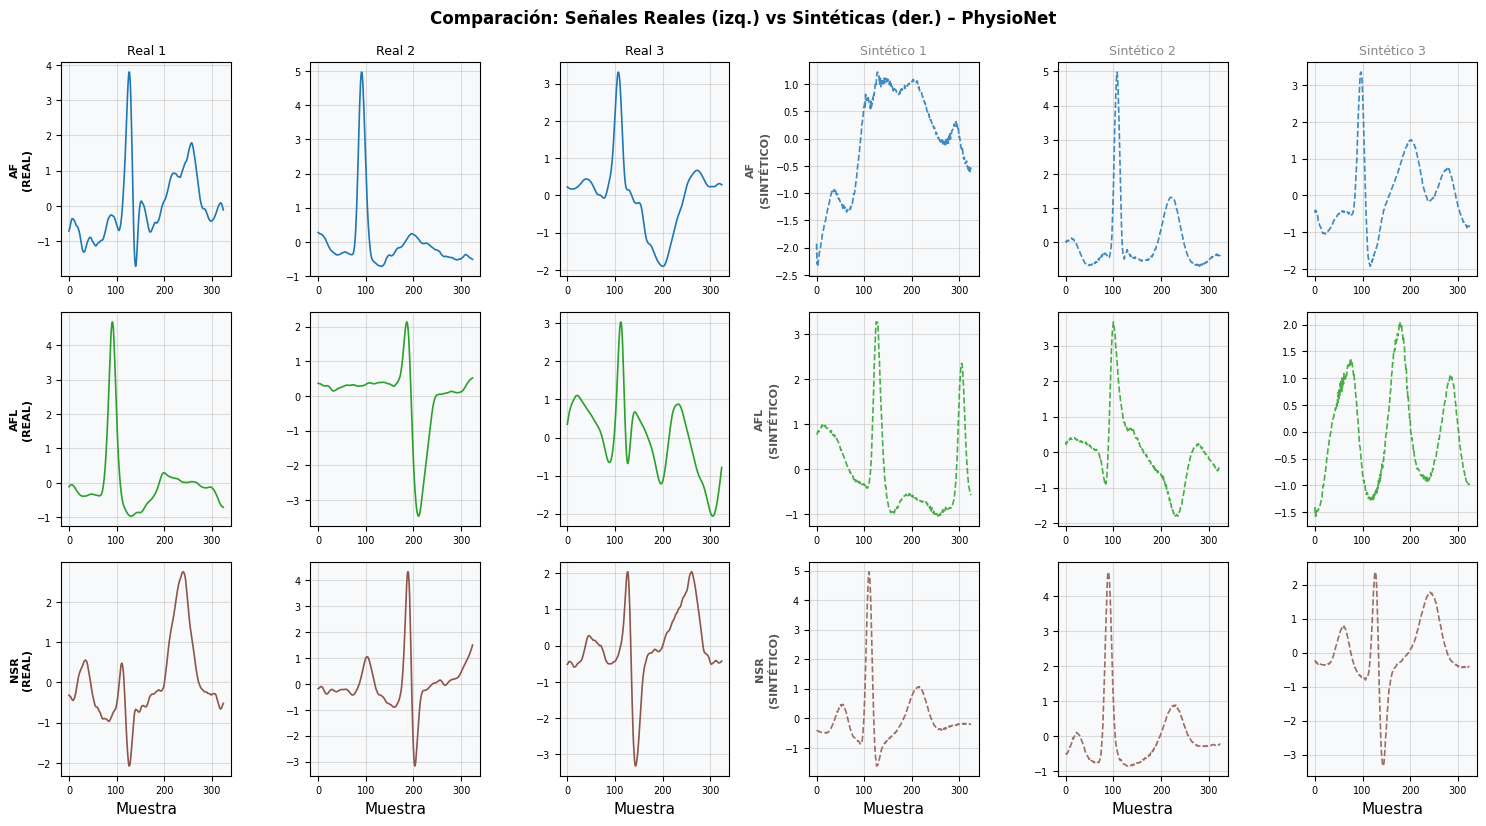

In [32]:
# ─────────────────────────────────────────────────────────
#  COMPARACIÓN: REAL vs SINTÉTICO
# ─────────────────────────────────────────────────────────

# Extraemos los datos del test_ds para la comparación
# Convertimos a numpy para facilitar la indexación con np.where
X_test_all = full_dataset.X[test_ds.indices].cpu().numpy()
y_test_all = full_dataset.y[test_ds.indices].cpu().numpy()

COMPARE_CLASSES = CLASS_NAMES[:min(3, N_CLASSES)]
N_COMP = 3

fig, axes = plt.subplots(len(COMPARE_CLASSES), N_COMP * 2,
                          figsize=(15, 2.8 * len(COMPARE_CLASSES)))
if len(COMPARE_CLASSES) == 1:
    axes = axes.reshape(1, -1)
fig.suptitle('Comparación: Señales Reales (izq.) vs Sintéticas (der.) – PhysioNet',
             fontsize=12, fontweight='bold')

for row, cls in enumerate(COMPARE_CLASSES):
    cls_idx    = CLASS_IDX[cls]
    col_color  = colors_map[cls]

    # Filtrar índices de la clase actual en el set de test
    real_idx = np.where(y_test_all == cls_idx)[0]
    chosen   = np.random.choice(real_idx, size=min(N_COMP, len(real_idx)), replace=False)
    X_real   = X_test_all[chosen].squeeze(1) # Quitar dimensión de canal (1, 325) -> (325,)

    x_syn = generate_from_bank(model, latent_bank, cls_idx, N_COMP, DEVICE)
    X_syn = x_syn.squeeze(1).cpu().numpy()

    for col in range(N_COMP):
        # --- Columna REAL ---
        ax = axes[row, col]
        ax.plot(t_idx_plot, X_real[col], color=col_color, linewidth=1.2)
        ax.tick_params(labelsize=7)
        if col == 0:
            ax.set_ylabel(f'{cls}\n(REAL)', fontsize=8, fontweight='bold')
        if row == 0:
            ax.set_title(f'Real {col+1}', fontsize=9)
        if row == len(COMPARE_CLASSES)-1:
            ax.set_xlabel('Muestra')

        # --- Columna SINTÉTICA ---
        ax2 = axes[row, col + N_COMP]
        ax2.plot(t_idx_plot, X_syn[col], color=col_color, linewidth=1.2,
                 linestyle='--', alpha=0.85)
        ax2.tick_params(labelsize=7)
        if col == 0:
            ax2.set_ylabel(f'{cls}\n(SINTÉTICO)', fontsize=8, fontweight='bold', color='#555')
        if row == 0:
            ax2.set_title(f'Sintético {col+1}', fontsize=9, color='#888')
        if row == len(COMPARE_CLASSES)-1:
            ax2.set_xlabel('Muestra')

plt.tight_layout()
plt.savefig('comparacion_real_sintetico_physionet.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Evaluación Cuantitativa del Generador TCN-cVAE

⏳ Evaluando el generador sobre señales reales de TEST...
✅ Clase AF: MMD²=0.00000 | SWD=0.08931 | Fréchet=0.0684
✅ Clase AFL: MMD²=0.00235 | SWD=0.11634 | Fréchet=0.1174
✅ Clase NSR: MMD²=0.00438 | SWD=0.14356 | Fréchet=0.0642
✅ Clase SB: MMD²=0.00033 | SWD=0.08118 | Fréchet=0.0869
✅ Clase ST: MMD²=0.00101 | SWD=0.10340 | Fréchet=0.0612

MÉTRICAS DEL GENERADOR POR CLASE


,Clase,Descripción,N evaluación,MMD² RBF,SWD,Fréchet latente,MAE media,Ratio diversidad,Coverage,Memorization rate
0,AF,AF,300,0.00000,0.08931,0.06838,0.04641,0.99266,0.53333,0.0
1,AFL,AFL,300,0.00235,0.11634,0.11742,0.07309,0.97497,0.47333,0.0
2,NSR,NSR,300,0.00438,0.14356,0.06418,0.07665,0.97511,0.47667,0.0
3,SB,SB,300,0.00033,0.08118,0.08693,0.06000,0.98088,0.52000,0.0
4,ST,ST,300,0.00101,0.10340,0.06123,0.04983,0.98809,0.52667,0.0



📊 PROMEDIO MACRO:
   MMD² RBF              : 0.00161
   SWD                   : 0.10676
   Fréchet latente       : 0.07963
   MAE media             : 0.06120
   MAE desviación        : 0.06463
   Ratio diversidad      : 0.98234
   Coverage              : 0.50600
   Memorization rate     : 0.00000


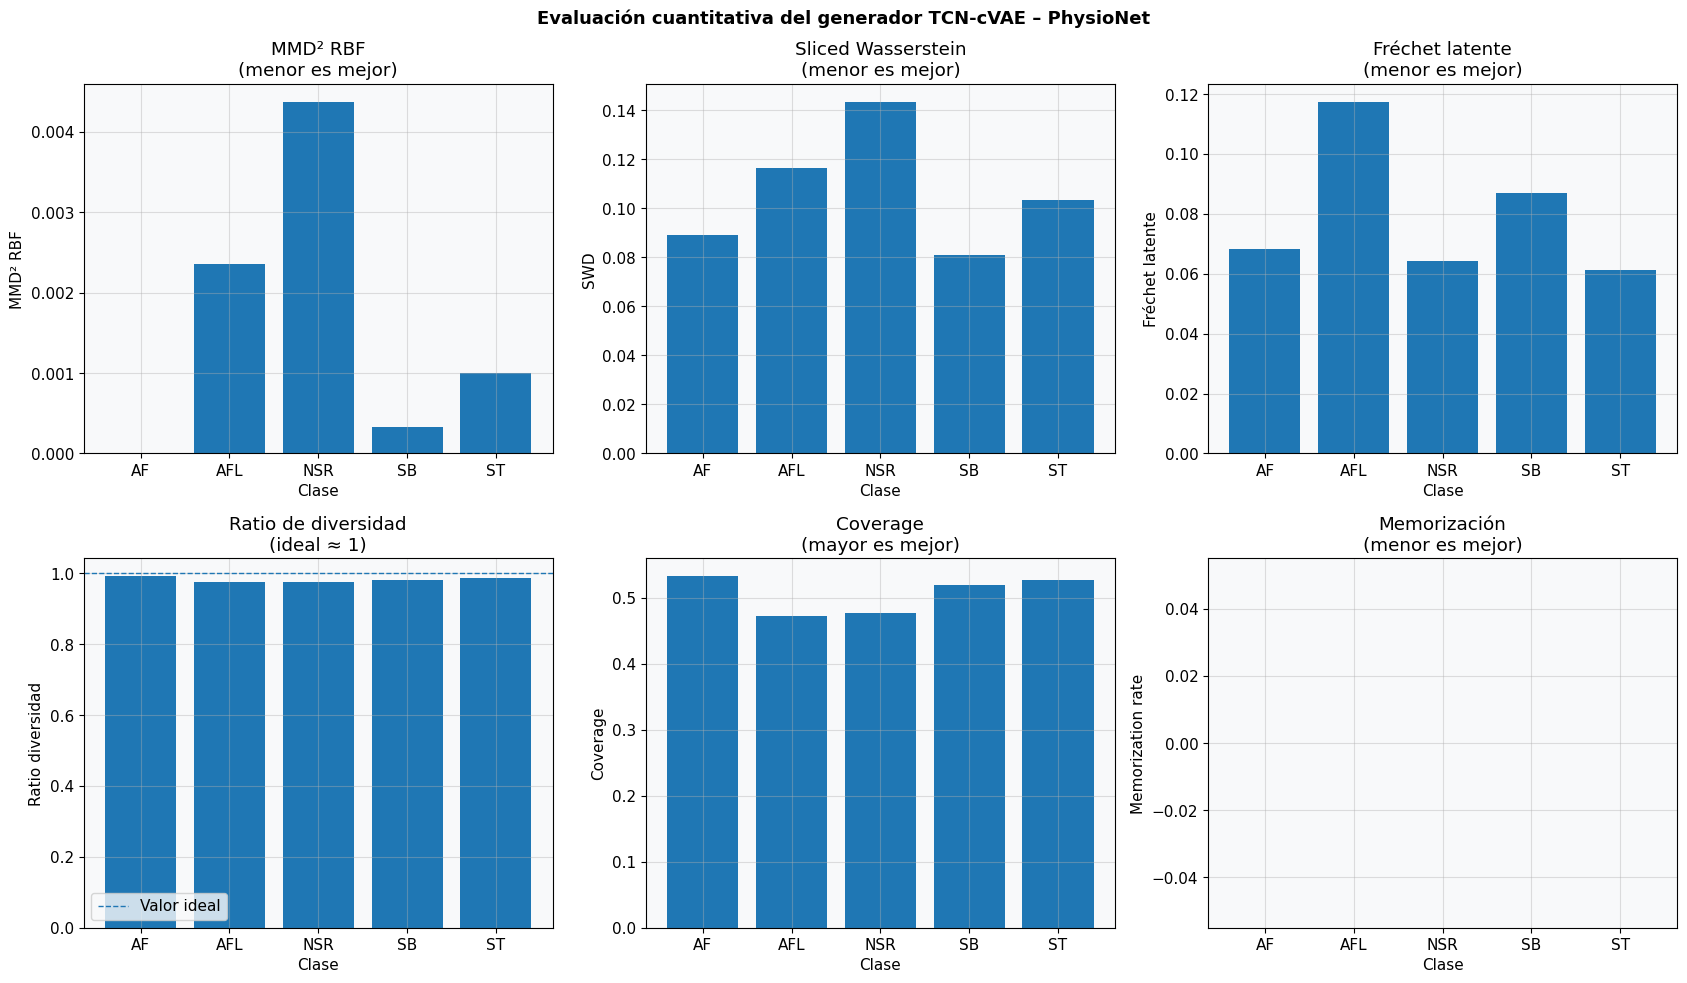

In [34]:
# ─────────────────────────────────────────────────────────
#  MÉTRICAS DEL GENERADOR TCN-cVAE
#
#  Se comparan señales sintéticas con señales reales del
#  conjunto TEST, que no fue utilizado para entrenar.
# ─────────────────────────────────────────────────────────

from scipy.spatial.distance import cdist, pdist
from scipy.stats import wasserstein_distance
from scipy.linalg import sqrtm

GENERATOR_EVAL_MAX = 300
N_PROJECTIONS = 64
GEN_BATCH_SIZE = 256
RNG_GENERATOR = np.random.default_rng(SEED)

# --- EXTRACCIÓN DE DATOS DE TEST PARA EVALUACIÓN ---
# Accedemos a los datos normalizados del dataset original usando los índices de test
X_test_eval = full_dataset.X[test_ds.indices].squeeze(1).cpu().numpy()
y_test_eval = full_dataset.y[test_ds.indices].cpu().numpy()

# ─────────────────────────────────────────────────────────
#  GENERACIÓN POR LOTES
# ─────────────────────────────────────────────────────────

@torch.no_grad()
def generate_class_samples(
    model,
    latent_bank,
    cls_idx,
    n_samples,
    device,
    batch_size=256
):
    """Genera señales sintéticas de una clase en varios lotes."""
    generated = []
    remaining = n_samples

    while remaining > 0:
        current_batch = min(batch_size, remaining)

        x_syn = generate_from_bank(
            model=model,
            latent_bank=latent_bank,
            cls_idx=cls_idx,
            n=current_batch,
            device=device
        )

        generated.append(
            x_syn.squeeze(1).detach().cpu().numpy()
        )
        remaining -= current_batch

    return np.concatenate(generated, axis=0).astype(np.float32)


# ─────────────────────────────────────────────────────────
#  REPRESENTACIÓN LATENTE
# ─────────────────────────────────────────────────────────

@torch.no_grad()
def encode_signals(
    model,
    signals,
    cls_idx,
    n_classes,
    device,
    batch_size=256
):
    """Obtiene el vector mu del encoder para cada señal."""
    model.eval()
    latent_vectors = []

    for start in range(0, len(signals), batch_size):
        batch = signals[start:start + batch_size]

        x = torch.tensor(
            batch,
            dtype=torch.float32,
            device=device
        ).unsqueeze(1)

        labels = torch.full(
            (len(batch),),
            cls_idx,
            dtype=torch.long,
            device=device
        )

        condition = F.one_hot(
            labels,
            num_classes=n_classes
        ).float()

        mu, _ = model.encoder(x, condition)
        latent_vectors.append(mu.cpu().numpy())

    return np.concatenate(latent_vectors, axis=0)


# ─────────────────────────────────────────────────────────
#  MMD CON KERNEL RBF
# ─────────────────────────────────────────────────────────

def mmd_rbf_squared(real, synthetic):
    n = len(real)
    m = len(synthetic)
    if n < 2 or m < 2: return np.nan

    combined = np.concatenate([real, synthetic], axis=0)
    sample_size = min(400, len(combined))
    idx = RNG_GENERATOR.choice(len(combined), sample_size, replace=False)
    sample = combined[idx]

    dist_squared = cdist(sample, sample, metric="sqeuclidean")
    positive_distances = dist_squared[dist_squared > 0]
    if len(positive_distances) == 0: return 0.0

    median_distance = np.median(positive_distances)
    gamma = 1.0 / (2.0 * median_distance + 1e-12)

    k_xx = np.exp(-gamma * cdist(real, real, metric="sqeuclidean"))
    k_yy = np.exp(-gamma * cdist(synthetic, synthetic, metric="sqeuclidean"))
    k_xy = np.exp(-gamma * cdist(real, synthetic, metric="sqeuclidean"))

    np.fill_diagonal(k_xx, 0)
    np.fill_diagonal(k_yy, 0)
    term_xx = k_xx.sum() / (n * (n - 1))
    term_yy = k_yy.sum() / (m * (m - 1))
    term_xy = 2.0 * k_xy.mean()

    return float(max(term_xx + term_yy - term_xy, 0.0))

# ─────────────────────────────────────────────────────────
#  SLICED WASSERSTEIN DISTANCE
# ─────────────────────────────────────────────────────────

def sliced_wasserstein_distance(real, synthetic, n_projections=64):
    n_features = real.shape[1]
    directions = RNG_GENERATOR.normal(size=(n_features, n_projections))
    directions /= (np.linalg.norm(directions, axis=0, keepdims=True) + 1e-12)
    real_projected = real @ directions
    synthetic_projected = synthetic @ directions
    distances = [wasserstein_distance(real_projected[:, i], synthetic_projected[:, i]) for i in range(n_projections)]
    return float(np.mean(distances))

# ─────────────────────────────────────────────────────────
#  DISTANCIA FRÉCHET EN EL ESPACIO LATENTE
# ─────────────────────────────────────────────────────────

def latent_frechet_distance(real_latent, synthetic_latent):
    if len(real_latent) < 2 or len(synthetic_latent) < 2: return np.nan
    mu_real, mu_syn = np.mean(real_latent, axis=0), np.mean(synthetic_latent, axis=0)
    cov_real = np.atleast_2d(np.cov(real_latent, rowvar=False))
    cov_syn = np.atleast_2d(np.cov(synthetic_latent, rowvar=False))
    eps = 1e-6
    identity = np.eye(cov_real.shape[0])
    cov_real = cov_real + eps * identity
    cov_syn = cov_syn + eps * identity
    covariance_mean = sqrtm(cov_real @ cov_syn)
    if np.iscomplexobj(covariance_mean): covariance_mean = covariance_mean.real
    mean_difference = mu_real - mu_syn
    distance = (mean_difference @ mean_difference + np.trace(cov_real + cov_syn - 2.0 * covariance_mean))
    return float(max(distance, 0.0))

# ─────────────────────────────────────────────────────────
#  DIVERSIDAD, COBERTURA Y MEMORIZACIÓN
# ─────────────────────────────────────────────────────────

def mean_pairwise_distance(signals):
    if len(signals) < 2: return np.nan
    return float(np.mean(pdist(signals, metric="euclidean")))

def coverage_and_memorization(real, synthetic):
    if len(real) < 2 or len(synthetic) < 1: return np.nan, np.nan
    real_real_distances = cdist(real, real, metric="euclidean")
    np.fill_diagonal(real_real_distances, np.inf)
    real_nn = np.min(real_real_distances, axis=1)
    reference_distance = np.median(real_nn)
    real_syn_distances = cdist(real, synthetic, metric="euclidean")
    nearest_synthetic_for_real = np.min(real_syn_distances, axis=1)
    nearest_real_for_synthetic = np.min(real_syn_distances, axis=0)
    coverage = np.mean(nearest_synthetic_for_real <= reference_distance)
    memorization = np.mean(nearest_real_for_synthetic <= 0.05 * reference_distance)
    return float(coverage), float(memorization)

# ─────────────────────────────────────────────────────────
#  EVALUACIÓN POR CLASE
# ─────────────────────────────────────────────────────────

generator_results = []
generator_samples = {}

model.eval()
print("⏳ Evaluando el generador sobre señales reales de TEST...")

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    # Filtrar señales reales del set de test corregido
    real_class = X_test_eval[y_test_eval == cls_idx]
    n_evaluation = min(GENERATOR_EVAL_MAX, len(real_class))

    if n_evaluation < 2:
        print(f"⚠️ Clase {cls_name}: no hay suficientes señales.")
        continue

    selected = RNG_GENERATOR.choice(len(real_class), size=n_evaluation, replace=False)
    real_eval = real_class[selected].astype(np.float32)
    synthetic_eval = generate_class_samples(model=model, latent_bank=latent_bank, cls_idx=cls_idx, n_samples=n_evaluation, device=DEVICE, batch_size=GEN_BATCH_SIZE)

    generator_samples[cls_name] = {"real": real_eval, "synthetic": synthetic_eval}

    real_latent = encode_signals(model, real_eval, cls_idx, NUM_CLASSES, DEVICE)
    synthetic_latent = encode_signals(model, synthetic_eval, cls_idx, NUM_CLASSES, DEVICE)

    mmd_value = mmd_rbf_squared(real_eval, synthetic_eval)
    swd_value = sliced_wasserstein_distance(real_eval, synthetic_eval, N_PROJECTIONS)
    frechet_value = latent_frechet_distance(real_latent, synthetic_latent)
    mean_waveform_mae = float(np.mean(np.abs(real_eval.mean(axis=0) - synthetic_eval.mean(axis=0))))
    std_waveform_mae = float(np.mean(np.abs(real_eval.std(axis=0) - synthetic_eval.std(axis=0))))
    real_diversity = mean_pairwise_distance(real_eval)
    synthetic_diversity = mean_pairwise_distance(synthetic_eval)
    diversity_ratio = synthetic_diversity / (real_diversity + 1e-12)
    coverage, memorization = coverage_and_memorization(real_eval, synthetic_eval)

    generator_results.append({
        "Clase": cls_name, "Descripción": class_desc[cls_name], "N evaluación": n_evaluation,
        "MMD² RBF": mmd_value, "SWD": swd_value, "Fréchet latente": frechet_value,
        "MAE media": mean_waveform_mae, "MAE desviación": std_waveform_mae,
        "Ratio diversidad": diversity_ratio, "Coverage": coverage, "Memorization rate": memorization
    })
    print(f"✅ Clase {cls_name}: MMD²={mmd_value:.5f} | SWD={swd_value:.5f} | Fréchet={frechet_value:.4f}")

generator_metrics_df = pd.DataFrame(generator_results)
numeric_columns = ["MMD² RBF", "SWD", "Fréchet latente", "MAE media", "MAE desviación", "Ratio diversidad", "Coverage", "Memorization rate"]
generator_macro = generator_metrics_df[numeric_columns].mean(numeric_only=True).to_dict()

print("\n" + "=" * 120 + "\nMÉTRICAS DEL GENERADOR POR CLASE\n" + "=" * 120)
display(generator_metrics_df[["Clase", "Descripción", "N evaluación", "MMD² RBF", "SWD", "Fréchet latente", "MAE media", "Ratio diversidad", "Coverage", "Memorization rate"]].round(5))

print("\n📊 PROMEDIO MACRO:")
for metric, value in generator_macro.items(): print(f"   {metric:<22}: {value:.5f}")

generator_metrics_df.to_csv("metricas_generador_physionet.csv", index=False)

# ─────────────────────────────────────────────────────────
#  VISUALIZACIÓN DE LAS MÉTRICAS
# ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Evaluación cuantitativa del generador TCN-cVAE – PhysioNet", fontsize=13, fontweight="bold")
plot_metrics = [("MMD² RBF", "MMD² RBF\n(menor es mejor)"), ("SWD", "Sliced Wasserstein\n(menor es mejor)"), ("Fréchet latente", "Fréchet latente\n(menor es mejor)"), ("Ratio diversidad", "Ratio de diversidad\n(ideal ≈ 1)"), ("Coverage", "Coverage\n(mayor es mejor)"), ("Memorization rate", "Memorización\n(menor es mejor)")]

for ax, (column, title) in zip(axes.flatten(), plot_metrics):
    ax.bar(generator_metrics_df["Clase"], generator_metrics_df[column])
    ax.set_title(title); ax.set_xlabel("Clase"); ax.set_ylabel(column)
    if column == "Ratio diversidad":
        ax.axhline(1.0, linestyle="--", linewidth=1, label="Valor ideal")
        ax.legend()

plt.tight_layout()
plt.savefig("metricas_generador_physionet.png", dpi=150, bbox_inches="tight")
plt.show()

## 17. Visualización del Espacio Latente (t-SNE)

⏳ Calculando t-SNE sobre 2000 puntos (32D → 2D)...


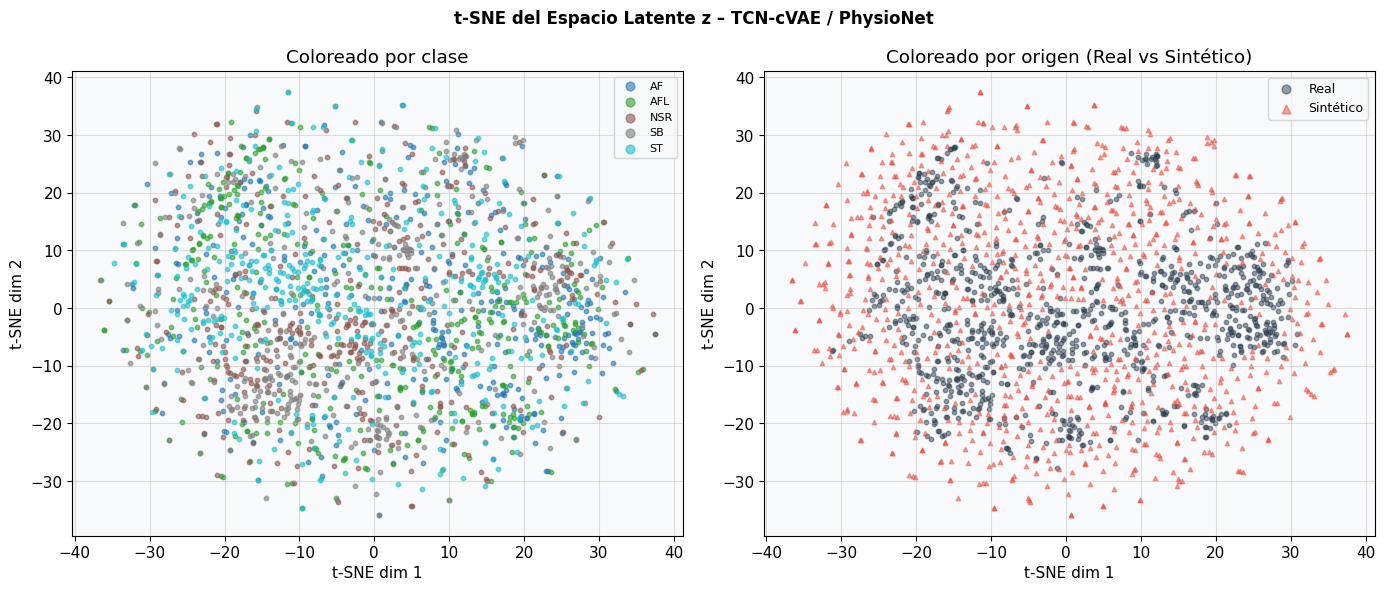

✅ t-SNE completado.


In [36]:
# ─────────────────────────────────────────────────────────
#  t-SNE DEL ESPACIO LATENTE
#  Si el cVAE aprendió bien, los clusters por clase deben
#  estar separados y los sintéticos deben mezclarse con
#  los reales de su misma clase.
# ─────────────────────────────────────────────────────────

# Corregimos la extracción de datos de test para el nuevo pipeline
X_test_tsne = full_dataset.X[test_ds.indices].cpu().numpy()
y_test_tsne = full_dataset.y[test_ds.indices].cpu().numpy()

N_TSNE = min(200, len(y_test_tsne) // N_CLASSES)

zs_real, zs_syn, labs_real, labs_syn = [], [], [], []

model.eval()
with torch.no_grad():
    for cls in CLASS_NAMES:
        cls_idx  = CLASS_IDX[cls]
        real_idx = np.where(y_test_tsne == cls_idx)[0]
        n        = min(N_TSNE, len(real_idx))
        if n == 0: continue

        chosen   = np.random.choice(real_idx, size=n, replace=False)

        # Los datos en full_dataset ya están normalizados (Z-score)
        x_r = torch.tensor(X_test_tsne[chosen], dtype=torch.float32).to(DEVICE)
        c_r = F.one_hot(torch.tensor([cls_idx]*n), num_classes=N_CLASSES).float().to(DEVICE)
        mu_r, _ = model.encoder(x_r, c_r)
        zs_real.append(mu_r.cpu().numpy())
        labs_real.extend([cls] * n)

        # Generar z sintético para la misma clase
        z_s = torch.randn(n, LATENT_DIM).to(DEVICE)
        zs_syn.append(z_s.cpu().numpy())
        labs_syn.extend([cls] * n)

Z_real = np.concatenate(zs_real, axis=0)
Z_syn  = np.concatenate(zs_syn,  axis=0)
Z_all  = np.concatenate([Z_real, Z_syn], axis=0)
origin = ['Real'] * len(Z_real) + ['Sintético'] * len(Z_syn)
labels_all = labs_real + labs_syn

print(f"⏳ Calculando t-SNE sobre {len(Z_all)} puntos ({LATENT_DIM}D → 2D)...")
tsne = TSNE(n_components=2, perplexity=min(40, len(Z_all)//5),
            n_iter=800, random_state=SEED, verbose=0)
Z_2d = tsne.fit_transform(Z_all)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('t-SNE del Espacio Latente z – TCN-cVAE / PhysioNet',
             fontsize=12, fontweight='bold')

for cls in CLASS_NAMES:
    mask = [l == cls for l in labels_all]
    ax1.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
               c=[colors_map[cls]], s=10, alpha=0.6,
               label=f'{cls}')
ax1.set_title('Coloreado por clase'); ax1.legend(fontsize=8, markerscale=2)
ax1.set_xlabel('t-SNE dim 1'); ax1.set_ylabel('t-SNE dim 2')

for orig, col, mk in [('Real', '#2c3e50', 'o'), ('Sintético', '#e74c3c', '^')]:
    mask = [o == orig for o in origin]
    ax2.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
               c=col, s=10, alpha=0.5, marker=mk, label=orig)
ax2.set_title('Coloreado por origen (Real vs Sintético)')
ax2.legend(fontsize=9, markerscale=2)
ax2.set_xlabel('t-SNE dim 1'); ax2.set_ylabel('t-SNE dim 2')

plt.tight_layout()
plt.savefig('tsne_latente_physionet.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ t-SNE completado.")

## 18. Resumen Automático del Pipeline y Resultados

In [ ]:
# ─────────────────────────────────────────────────────────
#  RESUMEN AUTOMÁTICO FINAL
#  Genera un resumen completo del pipeline ejecutado.
# ─────────────────────────────────────────────────────────

print('=' * 68)
print('   RESUMEN FINAL – TCN-cVAE / ECG5000')
print('=' * 68)

print('\n📊 DATASET')
print(f'   Nombre           : ECG5000')
print(f'   Total muestras   : {len(X_all):,}')
print(f'   Longitud señal   : {INPUT_LENGTH} puntos (frecuencia de muestreo no documentada)')
print(f'   Número de clases : {N_CLASSES}')
print(f'   Clases           : {list(zip(CLASS_NAMES, [class_desc[c] for c in CLASS_NAMES]))}')
print(f'   Split Train      : {len(X_train_norm):,}')
print(f'   Split Val        : {len(X_val_norm):,}')
print(f'   Split Test       : {len(X_test_norm):,}')

print('\n⚙️  PREPROCESAMIENTO')
print(f'   Segmentación     : Señales ya segmentadas en ECG5000 (no se re-segmentó)')
print(f'   Filtrado         : No aplicado (señales ya preprocesadas)')
print(f'   Normalización    : Z-score global (media/std del TRAIN)')
print(f'   División         : Estratificada por clase (sin patient-level split)')
print(f'   Balanceo         : WeightedRandomSampler + generación sintética cVAE')

print('\n🏗️  ARQUITECTURA')
print(f'   Modelo           : TCN-cVAE condicional')
print(f'   Input shape      : (B, 1, {INPUT_LENGTH})')
print(f'   Dim latente      : {LATENT_DIM}')
print(f'   Canales ocultos  : {HIDDEN_CH}')
print(f'   Dilataciones TCN : {DILATIONS}')
n_p = sum(p.numel() for p in model.parameters())
print(f'   Parámetros total : {n_p:,}')

print('\n📈 ENTRENAMIENTO')
epochs_ran = len(history['val_loss'])
best_ep    = int(np.argmin(history['val_recon'])) + 1
gap_fin    = history['generalization_gap'][-1]
print(f'   Épocas ejecutadas: {epochs_ran}  (máx. {MAX_EPOCHS})')
print(f'   Mejor época      : {best_ep}')
print(f'   Mejor val_recon  : {best_val_recon:.5f}')
print(f'   Gap final        : {gap_fin:+.5f}  ({"OK" if gap_fin < 0.01 else "Overfitting leve"})')

print('\n🎯 CLASIFICACIÓN DOWNSTREAM (Validación)')
print(f'   Accuracy Real         : {res_real["accuracy"]*100:.2f}%')
print(f'   Accuracy Real+Sintet. : {res_aug["accuracy"]*100:.2f}%')
delta = (res_aug['accuracy'] - res_real['accuracy'])*100
print(f'   Δ Accuracy            : {delta:+.2f}pp  ({"mejora" if delta>0 else "no mejora"})')
print(f'   AUC-ROC Real          : {res_real["auc_roc"]:.4f}')
print(f'   AUC-ROC Real+Sintet.  : {res_aug["auc_roc"]:.4f}')

print('\n⚠️  LIMITACIONES METODOLÓGICAS')
print('   1. Sin Patient-Level Split (ECG5000 no provee patient IDs)')
print('   2. Frecuencia de muestreo no documentada → sin intervalos en ms')
print('   3. Intervalos PR/QRS/QT no calculables sin frecuencia de muestreo conocida')
print('   4. Fidelidad evaluada con morfología relativa y distribución de amplitudes')
print('   5. ECG5000 no provee señales crudas ni metadatos de paciente')

print('\n📁 ARCHIVOS GUARDADOS')
for fname in [
    'distribucion_clases_ecg5000.png',
    'senales_por_clase_ecg5000.png',
    'normalizacion_ecg5000.png',
    'curvas_aprendizaje_ecg5000.png',
    'senales_sinteticas_ecg5000.png',
    'comparacion_real_sintetico_ecg5000.png',
    'matriz_confusion_ecg5000.png',
    'tsne_latente_ecg5000.png',
    'best_tcncvae_ecg5000.pt',
]:
    estado = '✅' if os.path.exists(fname) or fname.endswith('.pt') else '⏳'
    print(f'   {estado}  {fname}')

print('=' * 68)
